In [1]:
!pip install wandb huggingface_hub -q

In [2]:
from kaggle_secrets import UserSecretsClient
import wandb
from huggingface_hub import login, HfApi

user_secrets = UserSecretsClient()

wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_api_key)

hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

api = HfApi()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ojasavrathore_25afi13 (ojasavrathore_25afi13-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "ojasav-rathore/exp10-vit-resnet"

WANDB_PROJECT = "exp10-vit-resnet"
EPOCHS        = 4
BATCH_SIZE    = 128
NUM_CLASSES   = 10
PATCH_SIZE    = 4
IMG_SIZE      = 32
EMBED_DIM     = 128
NUM_HEADS     = 4
NUM_LAYERS    = 4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["ce", "label_smooth", "focal"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vit", "resnet18"]
AUG_MODES  = ["no_aug", "aug"]

class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
print(DEVICE)

cuda


### Dataset - Original and Augmented

100%|██████████| 170M/170M [00:02<00:00, 72.6MB/s] 


train=40000  val=10000  test=10000


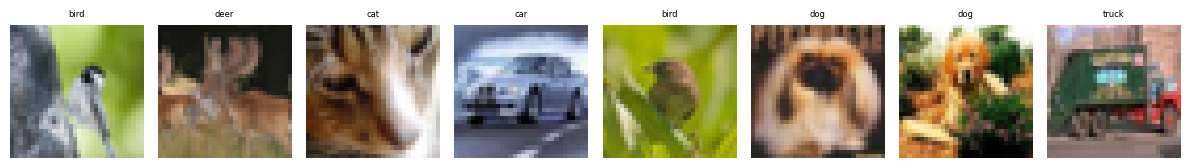

In [4]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# without augmentation
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# with horizontal + vertical flip
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_base)
full_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_aug)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

n_total = len(full_base)        # 50000
n_train = int(0.8 * n_total)   # 40000
n_val   = n_total - n_train    # 10000

gen = torch.Generator().manual_seed(42)
train_base, val_base = random_split(full_base, [n_train, n_val], generator=gen)
train_aug,  val_aug  = random_split(full_aug,  [n_train, n_val], generator=torch.Generator().manual_seed(42))

def make_loaders(train_set, val_set):
    tr = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vl = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    te = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return tr, vl, te

loaders = {
    'no_aug': make_loaders(train_base, val_base),
    'aug':    make_loaders(train_aug,  val_aug)
}

print(f'train={n_train}  val={n_val}  test={len(test_data)}')

imgs, labels = next(iter(loaders['no_aug'][0]))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    img = imgs[i].permute(1,2,0).numpy()
    img = img * np.array(std) + np.array(mean)
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Patch Embedding

In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = (img_size // patch_size) ** 2
        
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)    
        x = x.transpose(1, 2)
        return x

### Vision Transformer

In [6]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=10):
        super(ViT, self).__init__()

        self.patch_embed  = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches       = (img_size // patch_size) ** 2

        # learnable CLS token
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # learnable positional encoding
        self.pos_embed    = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm         = nn.LayerNorm(embed_dim)

        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        x   = self.transformer(x)
        x   = self.norm(x)

        out = self.head(x[:, 0])
        return out

### ResNet-18 Baseline

In [7]:
def get_resnet18():
    model = models.resnet18(weights=None)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, NUM_CLASSES)
    return model

### Loss Functions - CE, Label Smoothing, Focal

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def get_criterion(loss_type):
    if loss_type == 'ce':
        return nn.CrossEntropyLoss()
    elif loss_type == 'label_smooth':
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif loss_type == 'focal':
        return FocalLoss(gamma=2.0)

### Optimizer Factory

In [9]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

### Train and Eval Loops

In [10]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            loss  = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

### Main Experiment Runner

In [11]:
results       = {}
saved_models  = {}

def run_experiment(arch, loss_type, opt_name, aug_mode):
    name = f'{arch}_{loss_type}_{opt_name}_{aug_mode}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type,
        'optimizer': opt_name, 'augmentation': aug_mode, 'epochs': EPOCHS
    })

    train_loader, val_loader, test_loader = loaders[aug_mode]

    if arch == 'vit':
        model = ViT(
            img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
            embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
            num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
        ).to(DEVICE)
    else:
        model = get_resnet18().to(DEVICE)

    criterion = get_criterion(loss_type)
    optimizer = get_optimizer(model, opt_name)

    best_val_acc = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss':   vl_loss, 'val_acc':   vl_acc
        })
        print(f'  epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    # load best checkpoint and test
    model.load_state_dict(torch.load(f'{name}_best.pt'))
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    print(f'  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}')
    wandb.log({'test_loss': te_loss, 'test_acc': te_acc})

    results[name]      = {'test_acc': te_acc, 'test_loss': te_loss}
    saved_models[name] = model

    wandb.finish()
    return model

### Quick Test - run this first

In [12]:
run_experiment('vit',      'ce', 'adam', 'no_aug')
run_experiment('resnet18', 'ce', 'adam', 'no_aug')


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7869  train_acc=0.3266  val_loss=1.5928  val_acc=0.4077
  epoch 2/4  train_loss=1.4425  train_acc=0.4689  val_loss=1.3053  val_acc=0.5344
  epoch 3/4  train_loss=1.2483  train_acc=0.5409  val_loss=1.1750  val_acc=0.5703
  epoch 4/4  train_loss=1.1235  train_acc=0.5905  val_loss=1.1108  val_acc=0.5987
  test_loss=1.1249  test_acc=0.5905


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▆▇█
val_loss,█▄▂▁
epoch,4
test_acc,0.5905
test_loss,1.12486
train_acc,0.5905



starting: resnet18_ce_adam_no_aug


  epoch 1/4  train_loss=1.2552  train_acc=0.5465  val_loss=1.1222  val_acc=0.6186
  epoch 2/4  train_loss=0.7699  train_acc=0.7297  val_loss=0.8044  val_acc=0.7205
  epoch 3/4  train_loss=0.5786  train_acc=0.7980  val_loss=0.7298  val_acc=0.7528
  epoch 4/4  train_loss=0.4460  train_acc=0.8448  val_loss=0.6682  val_acc=0.7673
  test_loss=0.7062  test_acc=0.7645


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▆▇█
val_loss,█▃▂▁
epoch,4
test_acc,0.7645
test_loss,0.70615
train_acc,0.84485


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

### Full Grid - all combinations

In [13]:
for arch in MODELS:
    for aug in AUG_MODES:
        for lf in LOSS_FNS:
            for opt in OPTIMIZERS:
                run_experiment(arch, lf, opt, aug)


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7970  train_acc=0.3241  val_loss=1.6362  val_acc=0.3884
  epoch 2/4  train_loss=1.4721  train_acc=0.4531  val_loss=1.2952  val_acc=0.5255
  epoch 3/4  train_loss=1.2598  train_acc=0.5424  val_loss=1.2048  val_acc=0.5581
  epoch 4/4  train_loss=1.1355  train_acc=0.5932  val_loss=1.0747  val_acc=0.6085
  test_loss=1.0964  test_acc=0.6013


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▄▇█
train_loss,█▅▂▁
val_acc,▁▅▆█
val_loss,█▄▃▁
epoch,4
test_acc,0.6013
test_loss,1.09644
train_acc,0.59323



starting: vit_ce_sgd_no_aug


  epoch 1/4  train_loss=1.8989  train_acc=0.2928  val_loss=1.7289  val_acc=0.3600
  epoch 2/4  train_loss=1.6789  train_acc=0.3751  val_loss=1.5957  val_acc=0.4163
  epoch 3/4  train_loss=1.5694  train_acc=0.4221  val_loss=1.4895  val_acc=0.4460
  epoch 4/4  train_loss=1.4647  train_acc=0.4654  val_loss=1.3862  val_acc=0.4959
  test_loss=1.3936  test_acc=0.4907


...

  epoch 1/4  train_loss=1.1357  train_acc=0.3850  val_loss=0.9797  val_acc=0.4490
  epoch 2/4  train_loss=0.7861  train_acc=0.5438  val_loss=0.7284  val_acc=0.5744
  epoch 3/4  train_loss=0.6410  train_acc=0.6161  val_loss=0.6896  val_acc=0.6181
  epoch 4/4  train_loss=0.5474  train_acc=0.6623  val_loss=0.6495  val_acc=0.6153
  test_loss=0.6792  test_acc=0.6197


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▆██
val_loss,█▃▂▁
epoch,4
test_acc,0.6197
test_loss,0.67923
train_acc,0.66235



starting: resnet18_focal_rmsprop_aug


  epoch 1/4  train_loss=1.2322  train_acc=0.3599  val_loss=1.0662  val_acc=0.4219
  epoch 2/4  train_loss=0.8114  train_acc=0.5287  val_loss=1.0016  val_acc=0.4838
  epoch 3/4  train_loss=0.6403  train_acc=0.6091  val_loss=0.7399  val_acc=0.5542
  epoch 4/4  train_loss=0.5421  train_acc=0.6585  val_loss=0.6076  val_acc=0.6247
  test_loss=0.6101  test_acc=0.6217


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▃▆█
val_loss,█▇▃▁
epoch,4
test_acc,0.6217
test_loss,0.61015
train_acc,0.65848


### Results Summary

In [14]:
print(f'{"config":<50} {"test_acc":>10} {"test_loss":>10}')
print('-' * 72)
for k, v in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'{k:<50} {v["test_acc"]:>10.4f} {v["test_loss"]:>10.4f}')

best = max(results, key=lambda x: results[x]['test_acc'])
print(f'\nbest: {best}  acc={results[best]["test_acc"]:.4f}')

config                                               test_acc  test_loss
------------------------------------------------------------------------
resnet18_ce_adam_no_aug                                0.8019     0.6109
resnet18_label_smooth_adam_no_aug                      0.7763     1.0255
resnet18_focal_adam_no_aug                             0.7577     0.4074
resnet18_label_smooth_rmsprop_no_aug                   0.7266     1.1354
resnet18_ce_rmsprop_no_aug                             0.7125     0.8487
resnet18_label_smooth_adam_aug                         0.7029     1.1755
resnet18_label_smooth_sgd_no_aug                       0.7007     1.2281
resnet18_focal_adam_aug                                0.6967     0.4841
resnet18_ce_sgd_no_aug                                 0.6956     0.8779
resnet18_focal_sgd_no_aug                              0.6723     0.5946
resnet18_ce_sgd_aug                                    0.6707     0.9309
resnet18_ce_adam_aug                               

### Upload to HuggingFace

In [15]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_models.keys():
    fname = f'{name}_best.pt'
    if os.path.exists(fname):
        api.upload_file(
            path_or_fileobj=fname,
            path_in_repo=f'models/{fname}',
            repo_id=HF_REPO
        )
        print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: vit_ce_adam_no_aug_best.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

uploaded: resnet18_focal_sgd_aug_best.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: resnet18_focal_rmsprop_aug_best.pt
https://huggingface.co/ojasav-rathore/exp10-vit-resnet


In [16]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/ojasavrathore_25afi13-delhi-technological-university/exp10-vit-resnet
HF  : https://huggingface.co/ojasav-rathore/exp10-vit-resnet
